# Exploratory Data Analysis — Crypto Data Warehouse
**Kelompok 4 INT24 | Data Warehouse UAS 2025/2026**

Dataset: Yahoo Finance OHLCV (BTC, ETH, BNB, SOL, ADA) + Alternative.me Fear & Greed Index  
Periode: 2024-05-20 → 2026-05-19 | ~87.000 baris hourly + 730 baris daily sentiment

In [1]:
# ── 0. Import & Setup ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='darkgrid', palette='muted')

PROCESSED = Path('../data/processed')
SYMBOLS   = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD']
COLORS    = dict(zip(SYMBOLS, sns.color_palette('tab10', 5)))
print('Setup done')

✅ Setup done


In [2]:
# ── 1. Load Data ───────────────────────────────────────────────────────────────
# Load parquet hasil transform (lebih lengkap — sudah ada indikator)
def load_latest(prefix, ext='parquet'):
    files = sorted(PROCESSED.glob(f'{prefix}_*.{ext}'))
    if not files:
        # fallback ke CSV
        files = sorted(PROCESSED.glob(f'{prefix}_*.csv'))
        if not files:
            raise FileNotFoundError(f'No file found for {prefix}')
        return pd.read_csv(files[-1])
    return pd.read_parquet(files[-1])

df_daily  = load_latest('fact_market_daily')
df_hourly = load_latest('fact_market_hourly')
df_fng    = load_latest('fng')
dim_asset = load_latest('dim_asset')

# Merge symbol name ke fact_daily
df_daily = df_daily.merge(dim_asset[['asset_key','symbol']], on='asset_key', how='left')

df_daily['date'] = pd.to_datetime(df_daily['date'] if 'date' in df_daily.columns else df_daily['date_key'].astype(str))

print(f'fact_market_daily : {df_daily.shape}')
print(f'fact_market_hourly: {df_hourly.shape}')
print(f'fng               : {df_fng.shape}')
df_daily.head(3)

fact_market_daily : (3645, 20)
fact_market_hourly: (87308, 11)
fng               : (730, 3)


,fact_key,date_key,asset_key,sentiment_key,trend_key,open,high,low,close,volume,fng_value,daily_return,ma7,ma30,volatility_7d,rsi_14,volume_zscore,is_volume_anomaly,symbol,date
0,1459,20240520,1,4.0,7,66277.656250,71483.414062,66086.171875,71443.062500,2.516897e+10,70.0,NaN,71443.062500,71443.062500,NaN,NaN,NaN,False,BTC-USD,2024-05-20
1,1460,20240521,1,5.0,7,71427.992188,71785.109375,69229.679688,70135.320312,1.613142e+10,76.0,-0.018305,70789.191406,70789.191406,NaN,NaN,NaN,False,BTC-USD,2024-05-21
2,1461,20240522,1,5.0,7,70141.843750,70580.648438,69029.421875,69121.304688,2.160503e+09,76.0,-0.014458,70233.229167,70233.229167,0.00272,NaN,NaN,False,BTC-USD,2024-05-22


## 1. Overview Dataset

In [3]:
# ── 1.1 Missing Values ─────────────────────────────────────────────────────────
missing = df_daily.isnull().sum()
missing_pct = (missing / len(df_daily) * 100).round(2)
summary = pd.DataFrame({'missing': missing, 'pct (%)': missing_pct})
print('=== Missing Values — fact_market_daily ===')
print(summary[summary['missing'] > 0].to_string())

=== Missing Values — fact_market_daily ===
               missing  pct (%)
sentiment_key        5     0.14
fng_value            5     0.14
daily_return         5     0.14
volatility_7d       10     0.27
rsi_14              70     1.92
volume_zscore       20     0.55


In [4]:
# ── 1.2 Basic Statistics per Symbol ───────────────────────────────────────────
stats = df_daily.groupby('symbol')[['close','daily_return','volatility_7d','rsi_14','volume']].describe().round(4)
print('=== Descriptive Statistics per Symbol ===')
stats

=== Descriptive Statistics per Symbol ===


close                                                              \
         count        mean         std         min         25%         50%   
symbol                                                                       
ADA-USD  729.0      0.5690      0.2476      0.2363      0.3524      0.5422   
BNB-USD  729.0    701.8792    155.9080    464.6269    598.8176    647.3492   
BTC-USD  729.0  87414.6919  18833.3868  53949.0859  68785.0781  88429.5859   
ETH-USD  729.0   2933.4428    755.5645   1472.6014   2351.2000   2818.1355   
SOL-USD  729.0    155.5943     43.0987     77.7544    131.4726    150.1339   

                                  daily_return          ...   rsi_14           \
                 75%          max        count    mean  ...      75%      max   
symbol                                                  ...                     
ADA-USD       0.7614       1.2311        728.0  0.0003  ...  53.1002  89.9524   
BNB-USD     786.1412    1310.2277        728.0  0.0005  ...  57.9383  92.9970   
BTC-USD  103736.0078  124752.1406        728.0  0.0004  ...  60.4832  84.4367   
ETH-USD    3444.7041    4831.0884        728.0 -0.0001  ...  57.7043  87.4854   
SOL-USD     184.6862     261.8724        728.0 -0.0002  ...  57.1448  82.8087   

        volume                                                               \
         count          mean           std  min           25%           50%   
symbol                                                                        
ADA-USD  729.0  3.355583e+08  1.382341e+09  0.0  5.232237e+07  1.307018e+08   
BNB-USD  729.0  3.905042e+08  5.282824e+08  0.0  9.506150e+07  2.207982e+08   
BTC-USD  729.0  1.297656e+10  1.465313e+10  0.0  3.786564e+09  8.804377e+09   
ETH-USD  729.0  8.111996e+09  7.829227e+09  0.0  2.637062e+09  6.067243e+09   
SOL-USD  729.0  1.320222e+09  1.642966e+09  0.0  3.481647e+08  8.417510e+08   

                                     
                  75%           max  
symbol                               
ADA-USD  2.917181e+08  3.445158e+10  
BNB-USD  4.747444e+08  5.841256e+09  
BTC-USD  1.716224e+10  1.356637e+11  
ETH-USD  1.126602e+10  6.547945e+10  
SOL-USD  1.715992e+09  1.821055e+10  

[5 rows x 40 columns]

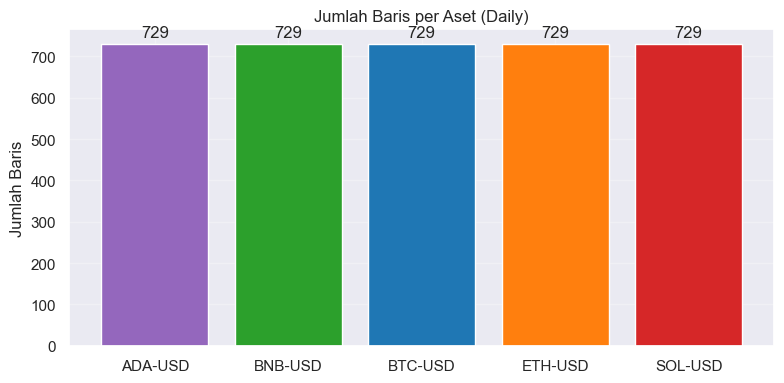

In [5]:
# ── 1.3 Row Count per Symbol ───────────────────────────────────────────────────
counts = df_daily.groupby('symbol').size().reset_index(name='rows')
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts['symbol'], counts['rows'], color=[COLORS[s] for s in counts['symbol']])
ax.bar_label(bars, padding=3)
ax.set_title('Jumlah Baris per Aset (Daily)')
ax.set_ylabel('Jumlah Baris')
plt.tight_layout()
plt.show()

## 2. Analisis Harga (Close Price)

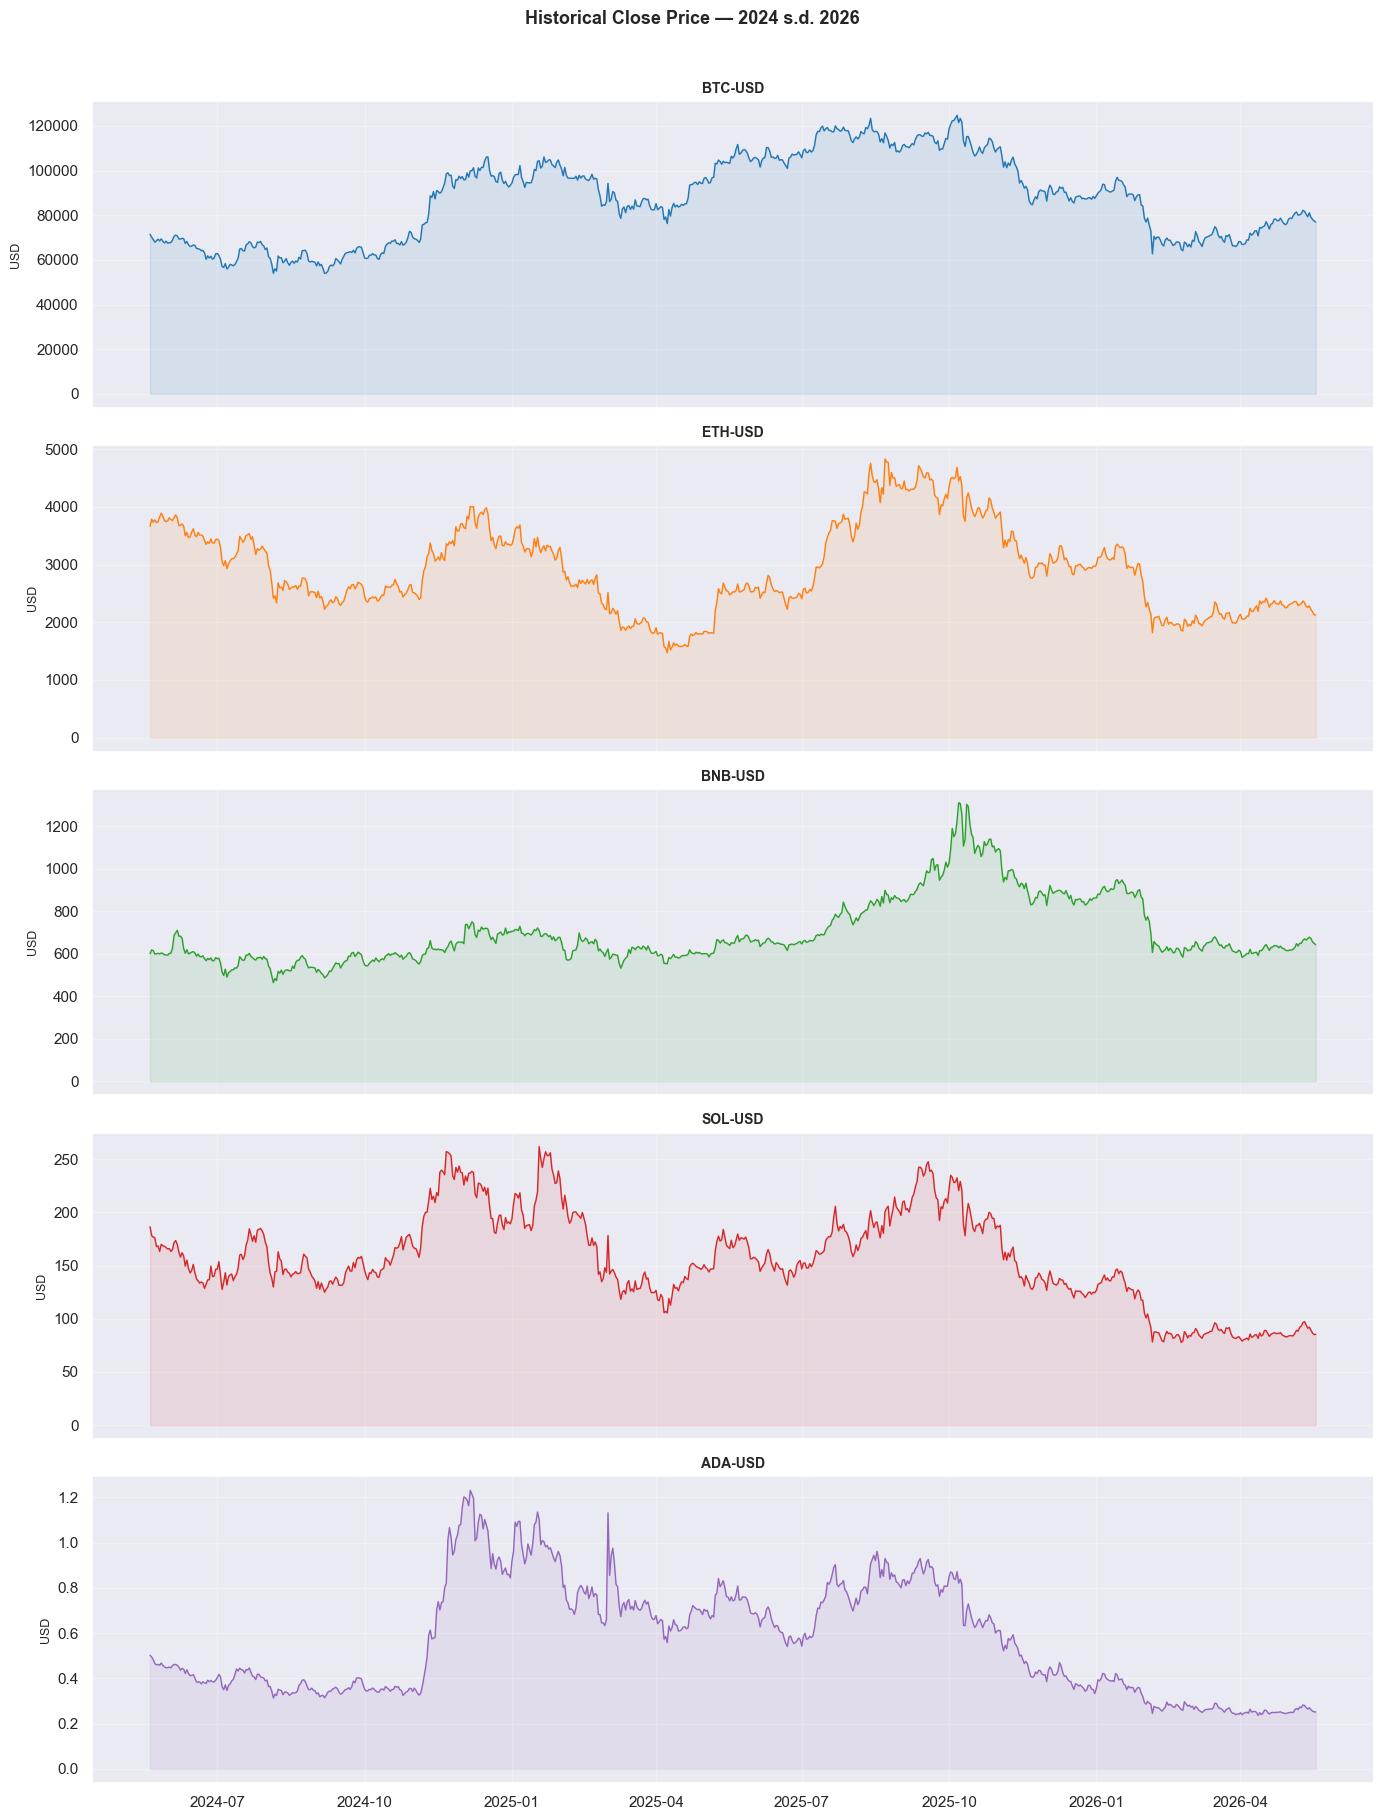

In [6]:
# ── 2.1 Time Series Harga ─────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
for ax, sym in zip(axes, SYMBOLS):
    data = df_daily[df_daily['symbol'] == sym].sort_values('date')
    ax.plot(data['date'], data['close'], color=COLORS[sym], linewidth=1)
    ax.fill_between(data['date'], data['close'], alpha=0.1, color=COLORS[sym])
    ax.set_ylabel('USD', fontsize=9)
    ax.set_title(sym, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.suptitle('Historical Close Price — 2024 s.d. 2026', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

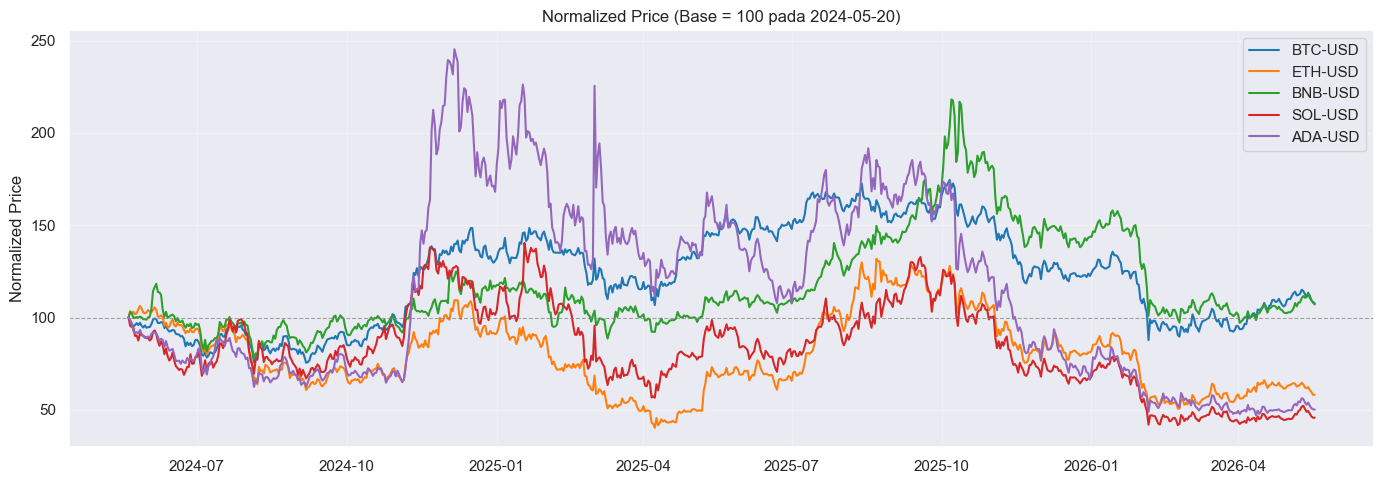

In [7]:
# ── 2.2 Normalized Price (base 100) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for sym in SYMBOLS:
    data = df_daily[df_daily['symbol'] == sym].sort_values('date')
    norm = data['close'] / data['close'].iloc[0] * 100
    ax.plot(data['date'], norm, label=sym, color=COLORS[sym], linewidth=1.5)
ax.axhline(100, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax.set_title('Normalized Price (Base = 100 pada 2024-05-20)')
ax.set_ylabel('Normalized Price')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Distribusi Daily Return

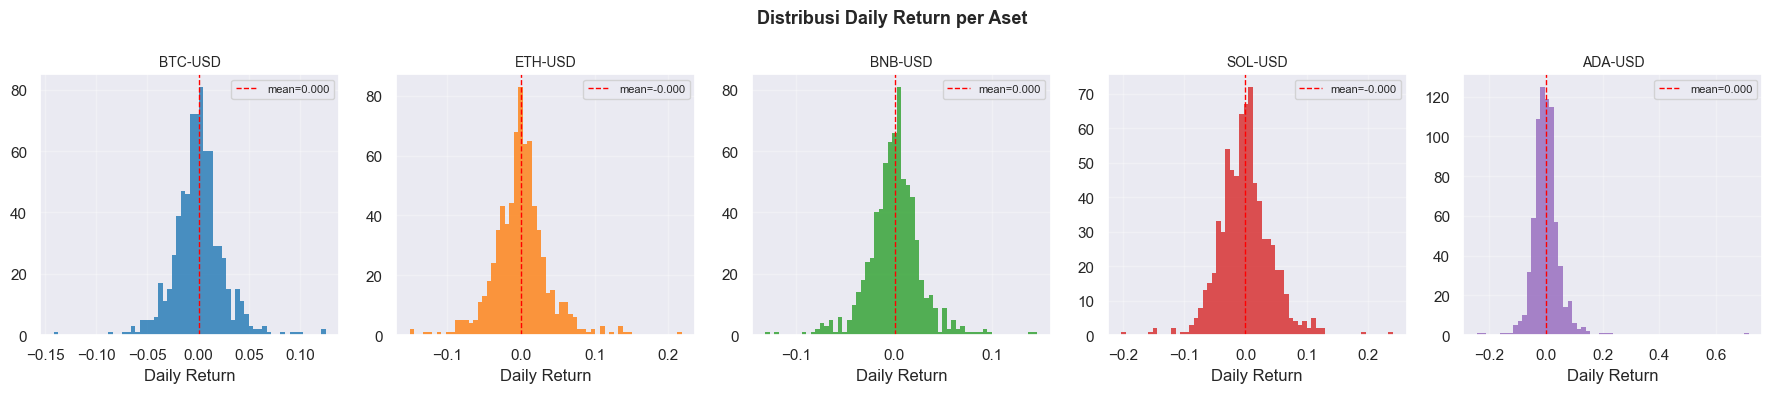

In [8]:
# ── 3.1 Distribusi Return per Aset ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, sym in zip(axes, SYMBOLS):
    data = df_daily[df_daily['symbol'] == sym]['daily_return'].dropna()
    ax.hist(data, bins=60, color=COLORS[sym], edgecolor='none', alpha=0.8)
    ax.axvline(data.mean(), color='red', linewidth=1, linestyle='--', label=f'mean={data.mean():.3f}')
    ax.set_title(sym, fontsize=10)
    ax.set_xlabel('Daily Return')
    ax.legend(fontsize=8)
fig.suptitle('Distribusi Daily Return per Aset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── 3.2 Outlier Detection (IQR) ───────────────────────────────────────────────
print('=== Outlier Summary (IQR Method) — Daily Return ===')
for sym in SYMBOLS:
    ret = df_daily[df_daily['symbol'] == sym]['daily_return'].dropna()
    q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
    iqr = q3 - q1
    outliers = ret[(ret < q1 - 1.5*iqr) | (ret > q3 + 1.5*iqr)]
    pct = len(outliers)/len(ret)*100
    print(f'  {sym:10s}: {len(outliers):4d} outliers ({pct:.2f}%)')

=== Outlier Summary (IQR Method) — Daily Return ===
  BTC-USD   :   34 outliers (4.67%)
  ETH-USD   :   38 outliers (5.22%)
  BNB-USD   :   39 outliers (5.36%)
  SOL-USD   :   22 outliers (3.02%)
  ADA-USD   :   32 outliers (4.40%)


## 4. Volatilitas

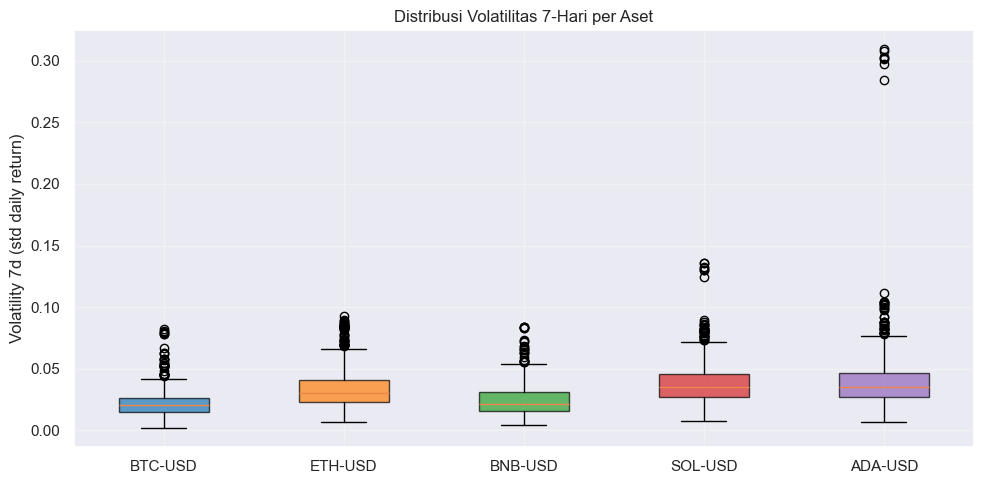

In [10]:
# ── 4.1 Boxplot Volatilitas 7d per Aset ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
data_vol = [df_daily[df_daily['symbol']==s]['volatility_7d'].dropna().values for s in SYMBOLS]
bp = ax.boxplot(data_vol, labels=SYMBOLS, patch_artist=True)
for patch, sym in zip(bp['boxes'], SYMBOLS):
    patch.set_facecolor(COLORS[sym])
    patch.set_alpha(0.7)
ax.set_title('Distribusi Volatilitas 7-Hari per Aset')
ax.set_ylabel('Volatility 7d (std daily return)')
plt.tight_layout()
plt.show()

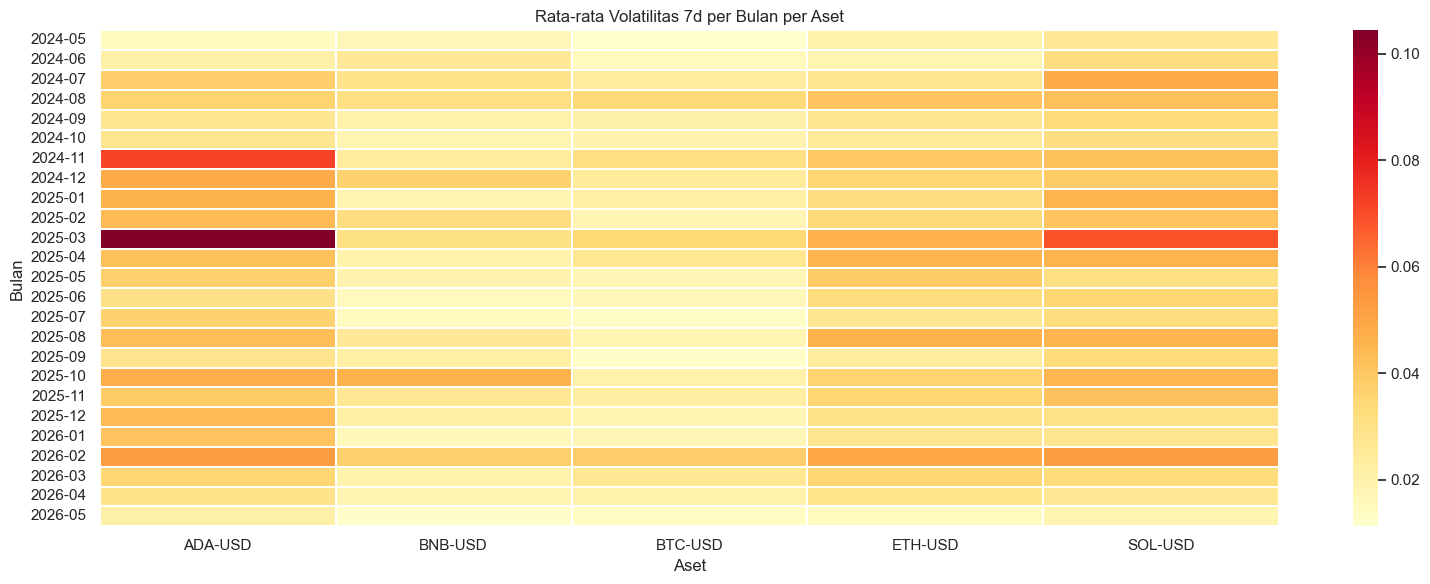

In [11]:
# ── 4.2 Volatilitas Bulanan (Heatmap) ─────────────────────────────────────────
df_daily['year_month'] = df_daily['date'].dt.to_period('M')
vol_pivot = df_daily.groupby(['symbol','year_month'])['volatility_7d'].mean().unstack(0).round(4)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(vol_pivot, cmap='YlOrRd', annot=False, linewidths=0.3, ax=ax)
ax.set_title('Rata-rata Volatilitas 7d per Bulan per Aset')
ax.set_xlabel('Aset')
ax.set_ylabel('Bulan')
plt.tight_layout()
plt.show()

## 5. Fear & Greed Index

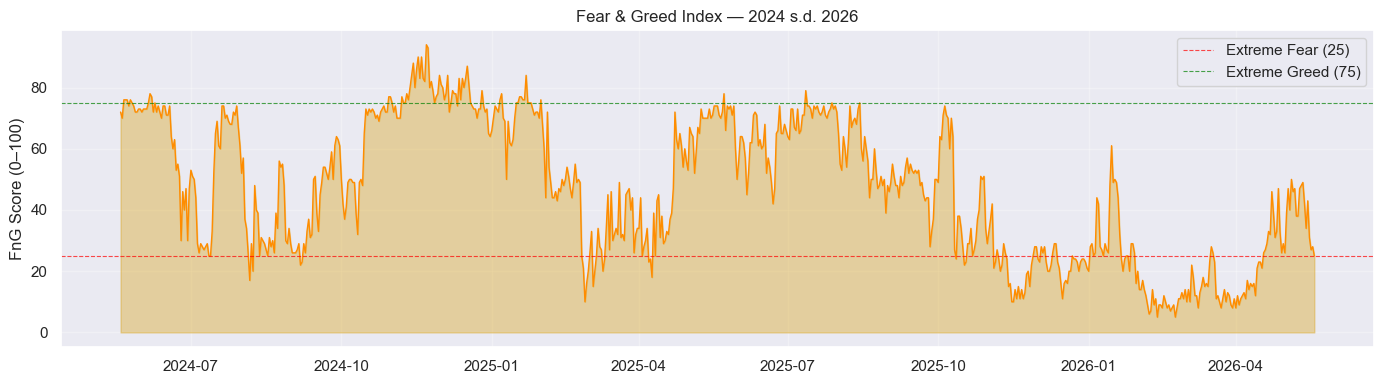

In [12]:
# ── 5.1 Time Series F&G ───────────────────────────────────────────────────────
df_fng['date'] = pd.to_datetime(df_fng['date'] if 'date' in df_fng.columns else df_fng['timestamp'], errors='coerce')
df_fng_sorted = df_fng.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 4))
fng_val = df_fng_sorted['fng_value'] if 'fng_value' in df_fng_sorted.columns else df_fng_sorted['value']
ax.fill_between(df_fng_sorted['date'], fng_val, alpha=0.4, color='goldenrod')
ax.plot(df_fng_sorted['date'], fng_val, color='darkorange', linewidth=1)
ax.axhline(25, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='Extreme Fear (25)')
ax.axhline(75, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='Extreme Greed (75)')
ax.set_title('Fear & Greed Index — 2024 s.d. 2026')
ax.set_ylabel('FnG Score (0–100)')
ax.legend()
plt.tight_layout()
plt.show()

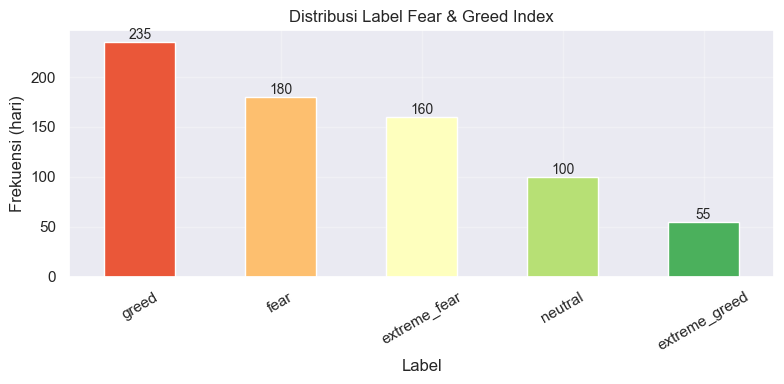

In [15]:
label_counts = df_fng['fng_classification'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot(kind='bar', ax=ax, color=sns.color_palette('RdYlGn', len(label_counts)))
ax.set_title('Distribusi Label Fear & Greed Index')
ax.set_xlabel('Label')
ax.set_ylabel('Frekuensi (hari)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Korelasi Sentimen vs Harga

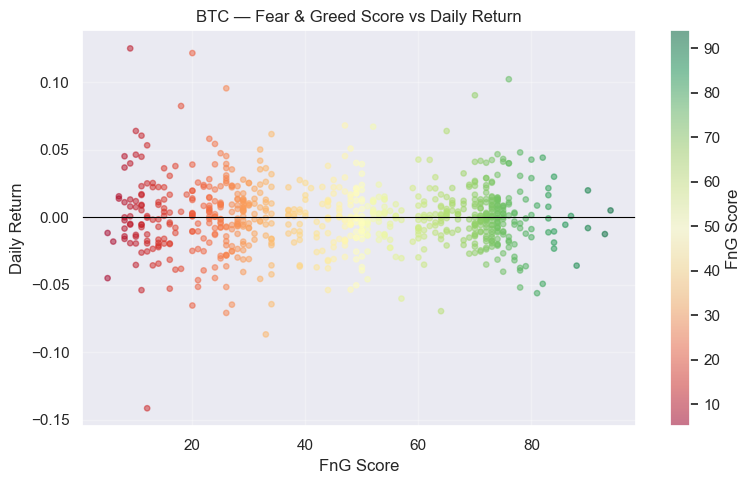

Korelasi Pearson FnG vs Daily Return (BTC): -0.0075


In [16]:
# ── 6.1 Scatter: FnG vs Daily Return ──────────────────────────────────────────
df_btc = df_daily[df_daily['symbol'] == 'BTC-USD'].dropna(subset=['fng_value','daily_return'])

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df_btc['fng_value'], df_btc['daily_return'],
                     c=df_btc['fng_value'], cmap='RdYlGn', alpha=0.5, s=15)
plt.colorbar(scatter, ax=ax, label='FnG Score')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('BTC — Fear & Greed Score vs Daily Return')
ax.set_xlabel('FnG Score')
ax.set_ylabel('Daily Return')
plt.tight_layout()
plt.show()

corr = df_btc[['fng_value','daily_return']].corr().iloc[0,1]
print(f'Korelasi Pearson FnG vs Daily Return (BTC): {corr:.4f}')

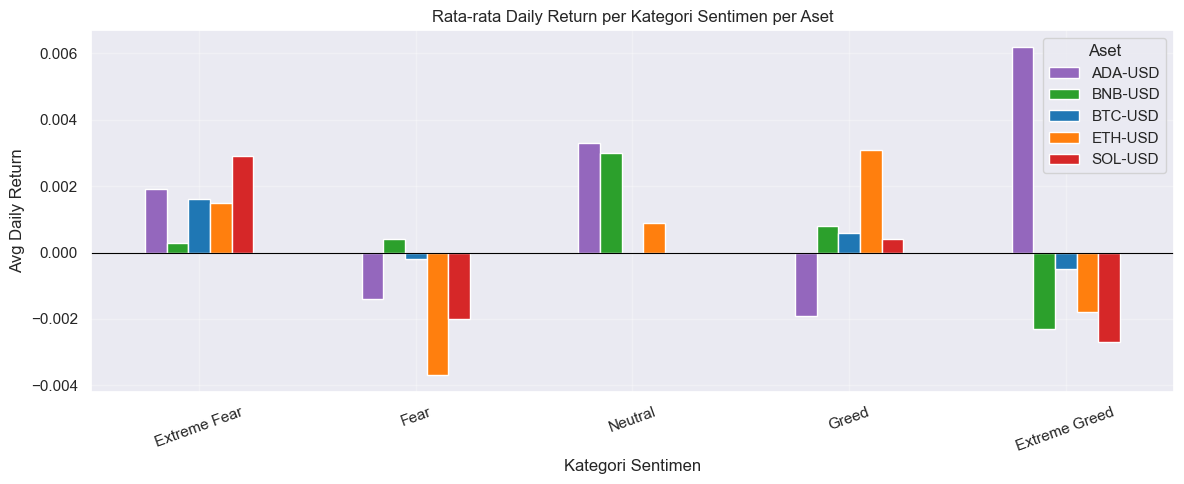

In [17]:
# ── 6.2 Rata-rata Return per Kategori Sentimen (semua aset) ───────────────────
sentiment_return = df_daily.dropna(subset=['fng_value','daily_return']).copy()

def classify_fng(v):
    if v <= 24: return 'Extreme Fear'
    if v <= 49: return 'Fear'
    if v <= 54: return 'Neutral'
    if v <= 74: return 'Greed'
    return 'Extreme Greed'

sentiment_return['fng_cat'] = sentiment_return['fng_value'].apply(classify_fng)
cat_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

avg_return = (sentiment_return.groupby(['symbol','fng_cat'])['daily_return']
              .mean().unstack('fng_cat')[cat_order].round(4))

fig, ax = plt.subplots(figsize=(12, 5))
avg_return.T.plot(kind='bar', ax=ax, color=[COLORS[s] for s in avg_return.index])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rata-rata Daily Return per Kategori Sentimen per Aset')
ax.set_xlabel('Kategori Sentimen')
ax.set_ylabel('Avg Daily Return')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.legend(title='Aset')
plt.tight_layout()
plt.show()

## 7. RSI & Trend

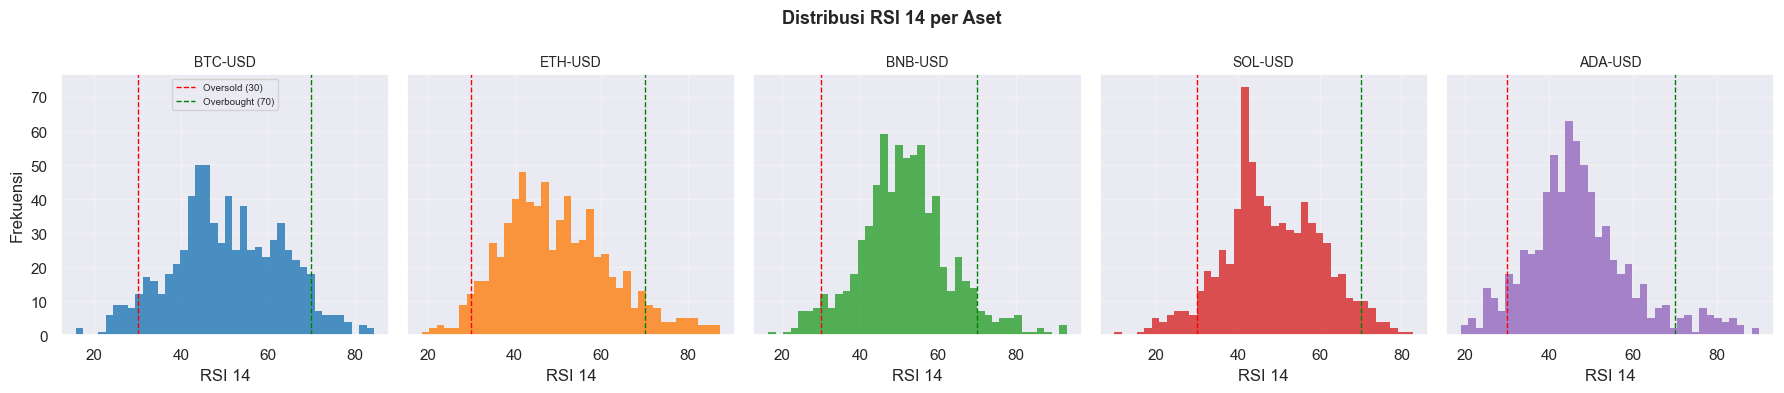

In [18]:
# ── 7.1 Distribusi RSI per Aset ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, sym in zip(axes, SYMBOLS):
    data = df_daily[df_daily['symbol']==sym]['rsi_14'].dropna()
    ax.hist(data, bins=40, color=COLORS[sym], alpha=0.8, edgecolor='none')
    ax.axvline(30, color='red', linestyle='--', linewidth=1, label='Oversold (30)')
    ax.axvline(70, color='green', linestyle='--', linewidth=1, label='Overbought (70)')
    ax.set_title(sym, fontsize=10)
    ax.set_xlabel('RSI 14')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=7)
fig.suptitle('Distribusi RSI 14 per Aset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
dim_trend = load_latest('dim_trend')
dim_sentiment = load_latest('dim_sentiment')

# Merge trend label
df_daily = df_daily.merge(dim_trend[['trend_key','trend_label','rsi_signal']], on='trend_key', how='left')

# Merge sentiment label  
df_daily = df_daily.merge(dim_sentiment[['sentiment_key','fng_label','fng_classification']], on='sentiment_key', how='left')

print('Kolom sekarang:', df_daily.columns.tolist())

Kolom sekarang: ['fact_key', 'date_key', 'asset_key', 'sentiment_key', 'trend_key', 'open', 'high', 'low', 'close', 'volume', 'fng_value', 'daily_return', 'ma7', 'ma30', 'volatility_7d', 'rsi_14', 'volume_zscore', 'is_volume_anomaly', 'symbol', 'date', 'year_month', 'trend_label', 'rsi_signal', 'fng_label', 'fng_classification']


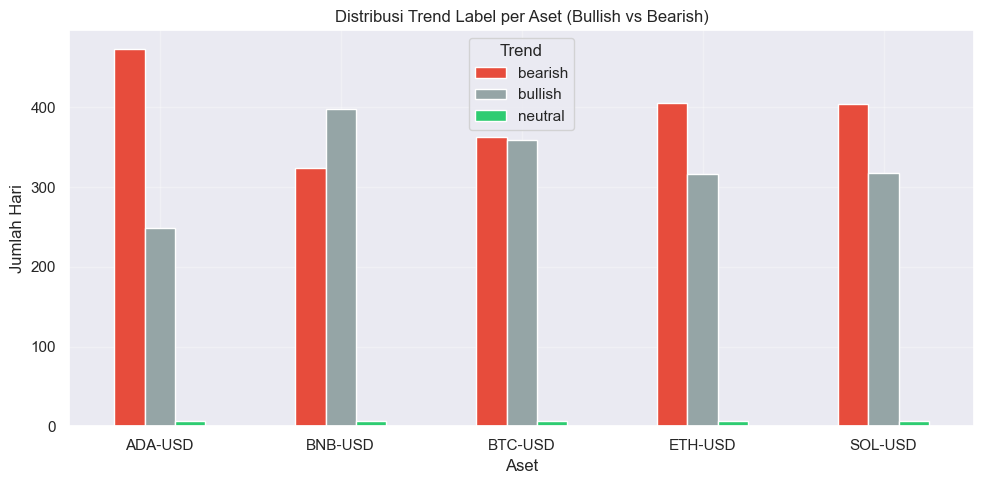

In [22]:
# ── 7.2 Trend Distribution (Bullish vs Bearish) ────────────────────────────────
trend_counts = df_daily.groupby(['symbol','trend_label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
trend_counts.plot(kind='bar', ax=ax, color=['#e74c3c','#95a5a6','#2ecc71'])
ax.set_title('Distribusi Trend Label per Aset (Bullish vs Bearish)')
ax.set_xlabel('Aset')
ax.set_ylabel('Jumlah Hari')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Trend')
plt.tight_layout()
plt.show()

## 8. Volume Anomaly

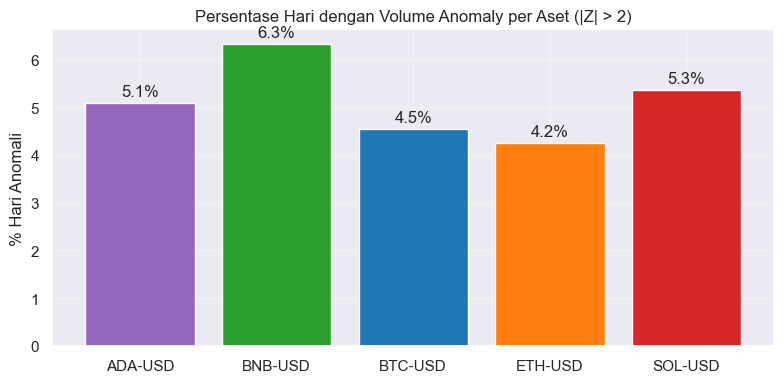

 symbol  anomaly_days  total_days  pct
ADA-USD            37         729 5.08
BNB-USD            46         729 6.31
BTC-USD            33         729 4.53
ETH-USD            31         729 4.25
SOL-USD            39         729 5.35


In [23]:
# ── 8.1 Volume Anomaly Count per Aset ─────────────────────────────────────────
anomaly_counts = df_daily.groupby('symbol')['is_volume_anomaly'].sum().reset_index()
anomaly_counts.columns = ['symbol','anomaly_days']
total_days = df_daily.groupby('symbol').size().reset_index(name='total_days')
anomaly_counts = anomaly_counts.merge(total_days, on='symbol')
anomaly_counts['pct'] = (anomaly_counts['anomaly_days'] / anomaly_counts['total_days'] * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(anomaly_counts['symbol'], anomaly_counts['pct'],
              color=[COLORS[s] for s in anomaly_counts['symbol']])
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in anomaly_counts['pct']], padding=3)
ax.set_title('Persentase Hari dengan Volume Anomaly per Aset (|Z| > 2)')
ax.set_ylabel('% Hari Anomali')
plt.tight_layout()
plt.show()

print(anomaly_counts.to_string(index=False))

## 9. Korelasi Antar Fitur

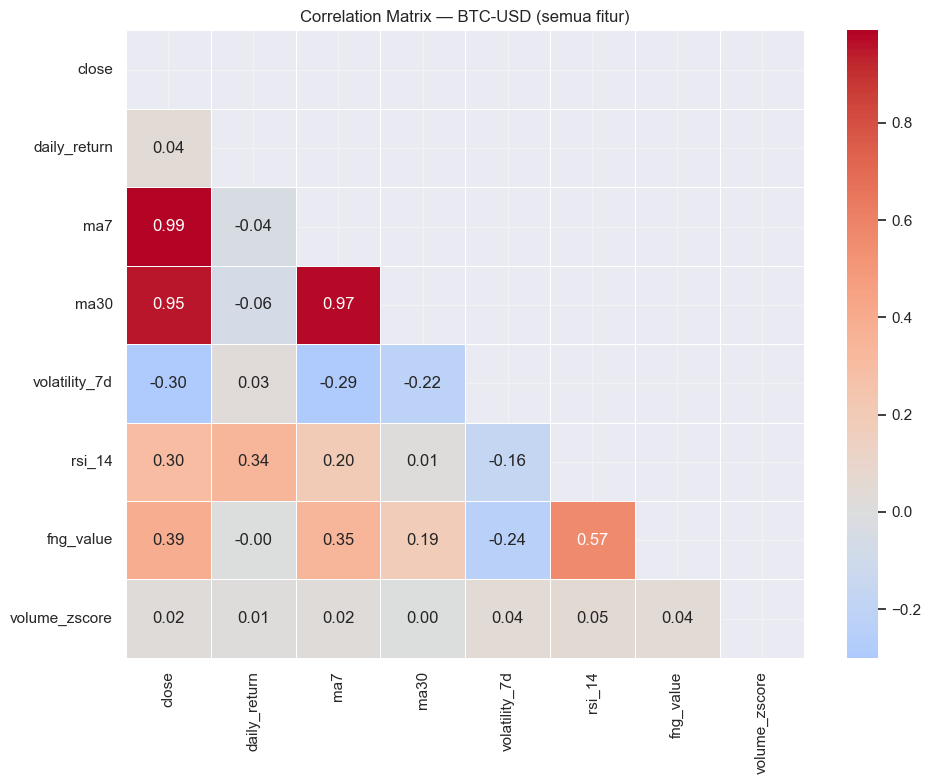

In [24]:
# ── 9.1 Correlation Heatmap (BTC sebagai contoh) ──────────────────────────────
features = ['close','daily_return','ma7','ma30','volatility_7d','rsi_14','fng_value','volume_zscore']
df_btc_feat = df_daily[df_daily['symbol']=='BTC-USD'][features].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_btc_feat.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — BTC-USD (semua fitur)')
plt.tight_layout()
plt.show()

## 10. Summary EDA

In [25]:
print('=' * 60)
print('RINGKASAN EDA — CRYPTO DATA WAREHOUSE')
print('=' * 60)
print(f'\n Total baris fact_market_daily : {len(df_daily):,}')
print(f' Total baris fact_market_hourly: {len(df_hourly):,}')
print(f' Periode data                  : 2024-05-20 → 2026-05-19')
print(f' Aset                          : {SYMBOLS}')

print('\n Volatilitas rata-rata per aset:')
for sym in SYMBOLS:
    v = df_daily[df_daily['symbol']==sym]['volatility_7d'].mean()
    print(f'   {sym:10s}: {v:.4f}')

print('\n Korelasi FnG vs Daily Return per aset:')
for sym in SYMBOLS:
    sub = df_daily[df_daily['symbol']==sym][['fng_value','daily_return']].dropna()
    c = sub.corr().iloc[0,1]
    print(f'   {sym:10s}: {c:.4f}')

print('\n EDA selesai.')

RINGKASAN EDA — CRYPTO DATA WAREHOUSE

 Total baris fact_market_daily : 3,645
 Total baris fact_market_hourly: 87,308
 Periode data                  : 2024-05-20 → 2026-05-19
 Aset                          : ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD']

 Volatilitas rata-rata per aset:
   BTC-USD   : 0.0219
   ETH-USD   : 0.0333
   BNB-USD   : 0.0242
   SOL-USD   : 0.0385
   ADA-USD   : 0.0413

 Korelasi FnG vs Daily Return per aset:
   BTC-USD   : -0.0075
   ETH-USD   : 0.0281
   BNB-USD   : 0.0147
   SOL-USD   : -0.0133
   ADA-USD   : 0.0089

 EDA selesai.
